In [1]:
from __future__ import annotations
from pathlib import Path
import polars as pl
import math
import re
import numpy as np
import pandas as pd
import pickle, time, logging, multiprocessing
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, UTC

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
warnings.filterwarnings("ignore", category=FutureWarning)
base_dir = Path(r"E:\Tennis Schema\data\raw")
cache_file = base_dir / "cached_tables.pkl"

groups = [
    ("raw_match_parquet", "event_", "MatchEventInfo"),
    ("raw_match_parquet", "home_team_", "MatchHomeTeamInfo"),
    ("raw_match_parquet", "away_team_", "MatchAwayTeamInfo"),
    ("raw_match_parquet", "home_team_score_", "MatchHomeScoreInfo"),
    ("raw_match_parquet", "away_team_score_", "MatchAwayScoreInfo"),
    ("raw_match_parquet", "tournament_", "MatchTournamentInfo"),
    ("raw_match_parquet", "season_", "MatchSeasonInfo"),
    ("raw_match_parquet", "round_", "MatchRoundInfo"),
    ("raw_match_parquet", "venue_", "MatchVenueInfo"),
    ("raw_match_parquet", "time_", "MatchTimeInfo"),
    ("raw_odds_parquet", "odds_", "OddsInfo"),
    ("raw_point_by_point_parquet", "pbp_", "GameInfo"),
    ("raw_statistics_parquet", "statistics_", "StatisticInfo"),
    ("raw_statistics_parquet", "period_", "PeriodInfo"),
    ("raw_tennis_power_parquet", "power_", "PowerInfo"),
    ("raw_votes_parquet", "votes_", "MatchVotesInfo"),
]

def scan_group(folder: str, prefix: str, table_name: str, base_dir: Path):
    folder_path = base_dir / folder
    if not folder_path.is_dir():
        return table_name, None, f"Folder not found: {folder_path}"
        
    parquet_paths = sorted(folder_path.glob(f"{prefix}*.parquet"))
    if not parquet_paths:
        return table_name, None, f"No parquet files found for {table_name}"

    try:
        scans = [pl.scan_parquet(p, low_memory=True) for p in parquet_paths]
        lazy = pl.concat(scans, how="diagonal_relaxed")
        df = lazy.collect(streaming=True).rechunk()
        return table_name, df, f"Loaded {table_name:25} → {df.shape} from {len(parquet_paths)} file(s)"
    except Exception as e:
        return table_name, None, f"Error loading {table_name}: {e}"

def main():
    start = time.time()
    dfs = {}
    if cache_file.exists():
        with open(cache_file, "rb") as f:
            dfs = pickle.load(f)
        logging.info("Data loaded from cache.")
    else:
        logging.info("No cache found. Loading from Parquet files...")

    cpu_cores = multiprocessing.cpu_count()
    max_workers = max(1, min(cpu_cores // 2, 8))
    logging.info(f"Detected {cpu_cores} CPU cores → using {max_workers} parallel threads.")

    tasks = [(f, p, n) for f, p, n in groups if n not in dfs]

    if tasks:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = {ex.submit(scan_group, f, p, n, base_dir): n for f, p, n in tasks}
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Loading Tables", ncols=90):
                name, df, msg = fut.result()
                logging.info(msg)
                if df is not None:
                    dfs[name] = df
    else:
        logging.info("All tables already cached.")

    if dfs:
        with open(cache_file, "wb") as f:
            pickle.dump(dfs, f, protocol=pickle.HIGHEST_PROTOCOL)
        logging.info("Cached all tables for next run.")

    print("\nSummary of loaded tables:")
    for name, df in dfs.items():
        try:
            shape = df.shape
        except Exception:
            shape = ("?", "?")
        print(f"{name:25} → {shape}")

    print(f"\nAll tables ready for analysis! (Execution time = {round(time.time() - start, 2)}s)")
    return dfs

if __name__ == "__main__":
    dfs = main()

KeyboardInterrupt: 

In [ ]:
# Save dfs output to CSV files
csv_output = Path(r"E:\Tennis Schema\data\raw\output.csv")

csv_output.mkdir(parents=True, exist_ok=True)
for name, df in dfs.items():
    try:
        df.write_csv(csv_output / f"{name}.csv")
        print(f"Saved CSV → {name}.csv")
    except Exception as e:
        print(f"Error saving {name}: {e}")

Saved CSV → MatchEventInfo.csv
Saved CSV → MatchHomeScoreInfo.csv
Saved CSV → MatchHomeTeamInfo.csv
Saved CSV → MatchAwayScoreInfo.csv
Saved CSV → MatchAwayTeamInfo.csv
Saved CSV → MatchTournamentInfo.csv
Saved CSV → MatchSeasonInfo.csv
Saved CSV → MatchRoundInfo.csv
Saved CSV → MatchVenueInfo.csv
Saved CSV → OddsInfo.csv
Saved CSV → GameInfo.csv
Saved CSV → MatchTimeInfo.csv
Saved CSV → StatisticInfo.csv
Saved CSV → PowerInfo.csv
Saved CSV → MatchVotesInfo.csv


In [ ]:
csv_dir = Path(r"E:\Tennis Schema\data\raw\output.csv")
csv_files = {
    "MatchHomeTeamInfo": csv_dir / "MatchHomeTeamInfo.csv",
    "MatchAwayTeamInfo": csv_dir / "MatchAwayTeamInfo.csv",
    "MatchEventInfo": csv_dir / "MatchEventInfo.csv",
    "MatchTournamentInfo": csv_dir / "MatchTournamentInfo.csv",
    "StatisticInfo": csv_dir / "StatisticInfo.csv",
    "PowerInfo": csv_dir / "PowerInfo.csv",
    "MatchVotesInfo": csv_dir / "MatchVotesInfo.csv",
    "MatchTimeInfo": csv_dir / "MatchTimeInfo.csv",
    "MatchSeasonInfo": csv_dir / "MatchSeasonInfo.csv",
    "MatchRoundInfo": csv_dir / "MatchRoundInfo.csv",
    "MatchVenueInfo": csv_dir / "MatchVenueInfo.csv",
    "OddsInfo": csv_dir / "OddsInfo.csv",
    "GameInfo": csv_dir / "GameInfo.csv",
    "MatchHomeScoreInfo": csv_dir / "MatchHomeScoreInfo.csv",
    "MatchAwayScoreInfo": csv_dir / "MatchAwayScoreInfo.csv"
}

In [ ]:
# Question 1 . How many tennis players are included in the dataset?
num_players = (
    pl.concat([
        pl.read_csv(csv_files["MatchHomeTeamInfo"]),
        pl.read_csv(csv_files["MatchAwayTeamInfo"])
    ])
    .select("player_id")
    .unique()
    .filter(pl.col("player_id").is_not_null())
    .height
)
print(f"Number of players: {num_players}")

Number of players: 2644


Average unique player height: 1.82 cm


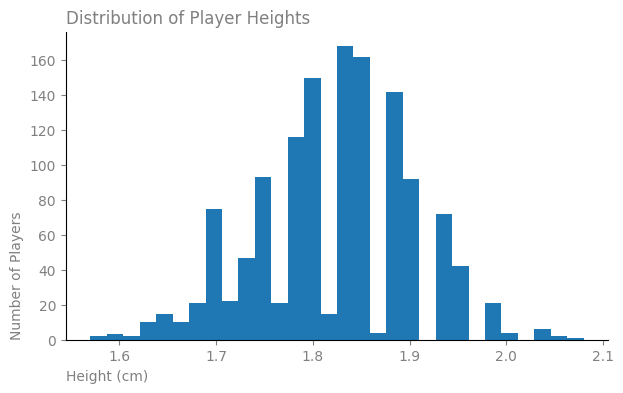

In [ ]:
# Question 2: Average height of players
unique_players = (
    pl.concat([
        pl.read_csv(csv_files["MatchHomeTeamInfo"]).select(["player_id", "height"]),
        pl.read_csv(csv_files["MatchAwayTeamInfo"]).select(["player_id", "height"])
    ])
    .unique(subset=["player_id"])      
    .drop_nulls(subset=["height"])     
)
avg_height = unique_players.select(pl.col("height").mean()).item()
print(f"Average unique player height: {round(avg_height, 2)} cm")
plt.figure(figsize=(7, 4))
plt.hist(unique_players["height"], bins=30, edgecolor="none")
plt.xlabel("Height (cm)", loc='left', color='gray')
plt.ylabel("Number of Players", loc='bottom', color='gray')
plt.title("Distribution of Player Heights", loc='left', color='gray')
plt.tick_params(axis='x', colors='gray')
plt.tick_params(axis='y', colors='gray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig("player_heights.png", dpi=300, bbox_inches="tight", transparent=False)
plt.show()

Number of matches with missing winner: 28219
shape: (10, 2)
┌─────────────────────────────────┬──────┐
│ full_name                       ┆ wins │
│ ---                             ┆ ---  │
│ str                             ┆ u32  │
╞═════════════════════════════════╪══════╡
│ Popko, Dmitry                   ┆ 58   │
│ Chidekh, Clement                ┆ 46   │
│ Jianu, Filip Cristian           ┆ 42   │
│ Faria, Jaime                    ┆ 42   │
│ Gengel, Marek                   ┆ 40   │
│ Dellien Velasco, Murkel Alejan… ┆ 40   │
│ Merida Aguilar, Daniel          ┆ 38   │
│ Kužmová, Katarína               ┆ 38   │
│ Helgo, Malene                   ┆ 38   │
│ Clarke, Jay                     ┆ 37   │
└─────────────────────────────────┴──────┘


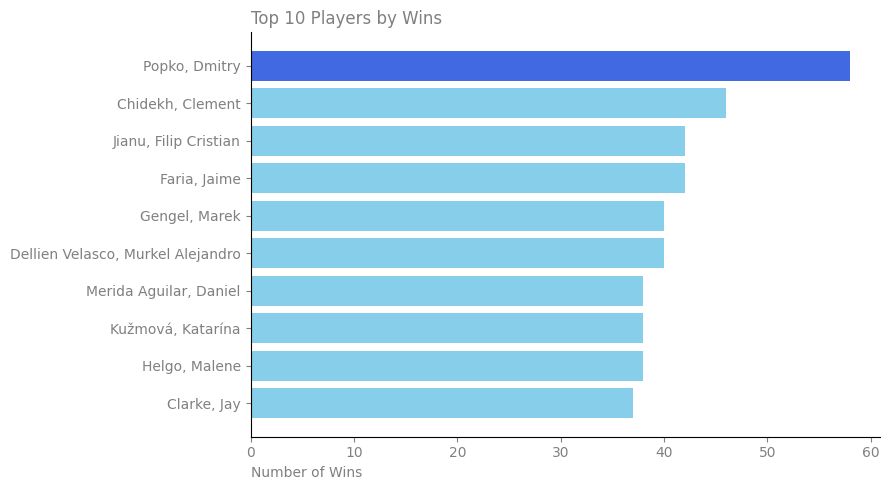

In [ ]:
# Question 3 . Which player has the highest number of wins?
winner_home_codes = ["home", "h", "1"]
winner_away_codes = ["away", "a", "2"]
merged = (
    pl.read_csv(csv_dir / "MatchEventInfo.csv")
      .join(pl.read_csv(csv_dir / "MatchHomeTeamInfo.csv"), on="match_id", how="left")
      .join(pl.read_csv(csv_dir / "MatchAwayTeamInfo.csv"), on="match_id", how="left", suffix="_away")
)
merged = merged.with_columns(
    pl.when(pl.col("winner_code").cast(pl.Utf8).str.strip_chars().str.to_lowercase().is_in(winner_home_codes))
      .then(pl.col("player_id"))
    .when(pl.col("winner_code").cast(pl.Utf8).str.strip_chars().str.to_lowercase().is_in(winner_away_codes))
      .then(pl.col("player_id_away"))
    .otherwise(None)
    .alias("winner_id")
)
print("Number of matches with missing winner:", merged.filter(pl.col("winner_id").is_null()).height)
players = (
    pl.concat([
        pl.read_csv(csv_dir / "MatchHomeTeamInfo.csv").select(["player_id", "full_name"]),
        pl.read_csv(csv_dir / "MatchAwayTeamInfo.csv").select(["player_id", "full_name"])
    ])
    .unique(subset=["player_id"])
    .filter(pl.col("full_name").str.to_lowercase() != "unknown")
)
winners = (
    merged.filter(pl.col("winner_id").is_not_null())
          .group_by("winner_id")
          .agg(pl.len().alias("wins"))
          .join(players, left_on="winner_id", right_on="player_id", how="left")
          .filter(pl.col("full_name").is_not_null())
          .sort("wins", descending=True)
)
top10 = winners.head(10)
print(top10.select(["full_name", "wins"]))
plt.figure(figsize=(9,5))
colors = ["skyblue"] * len(top10)
colors[0] = "royalblue"   
plt.barh(top10["full_name"], top10["wins"], color=colors, edgecolor="none")
plt.xlabel("Number of Wins", loc='left', color='gray')
plt.title("Top 10 Players by Wins", loc='left', color='gray', fontsize=12)
plt.gca().invert_yaxis() 
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().tick_params(axis='y', colors='gray')
plt.gca().tick_params(axis='x', colors='gray')
plt.tight_layout()
plt.savefig("Top 10 Players by Wins.png", dpi=300)
plt.show()

In [ ]:
# Question 4 .What is the longest match recorded in terms of duration?
# timeinfo['period_5'].notna().any(),timeinfo['period_4'].notna().any() : null 
timeinfo = pd.read_csv(csv_files["MatchTimeInfo"])
timeinfo = timeinfo[~timeinfo['period_1'].isna()]
for col in ['period_1', 'period_2']:
    Q1 = timeinfo[col].quantile(0.25)
    Q3 = timeinfo[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    timeinfo = timeinfo[(timeinfo[col] > lower_fence) & (timeinfo[col] < upper_fence)]
Q1 = timeinfo['period_3'].quantile(0.25)
Q3 = timeinfo['period_3'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
timeinfo = timeinfo[((timeinfo['period_3'] > lower_fence) & (timeinfo['period_3'] < upper_fence)) |
                    (timeinfo['period_3'].isna())]
timeinfo['total_time'] = timeinfo[['period_1', 'period_2', 'period_3']].sum(axis=1)
timeinfo['total_time_hm'] = timeinfo['total_time'].apply(lambda x: f"{int(x//3600)}:{int((x%3600)//60):02d}")
finaltimeinfo = timeinfo[['match_id','total_time','total_time_hm']].sort_values(by='total_time', ascending=False).head(5)
finaltimeinfo

,match_id,total_time,total_time_hm
467,12024245,13204.0,3:40
1732,12046963,12914.0,3:35
3797,12072523,12762.0,3:32
13798,12171560,12600.0,3:30
5465,12088096,12575.0,3:29


In [ ]:
# Question 5 . How many sets are typically played in a tennis match?
timeinfo['Total_match_period'] = timeinfo[['period_1' ,'period_2' ,'period_3']].count(axis=1) 
mean_ofSets = timeinfo['Total_match_period'].mean().round(2)
print(f"On average,{mean_ofSets} sets are typically played in a tennis match.")

On average,2.3 sets are typically played in a tennis match.


           country  weighted_score_per_player
0           Poland                      0.291
1           Serbia                      0.268
2          Belarus                      0.183
3          Tunisia                      0.167
4           Latvia                      0.111
5           Greece                      0.101
6           Norway                      0.083
7       Kazakhstan                      0.081
8          Denmark                      0.077
9            Italy                      0.070
10           Spain                      0.065
11          Russia                      0.056
12             USA                      0.050
13  Czech Republic                      0.047
14        Bulgaria                      0.046
15          Brazil                      0.045
16         Germany                      0.039
17         Ukraine                      0.035
18           China                      0.034
19          Canada                      0.030


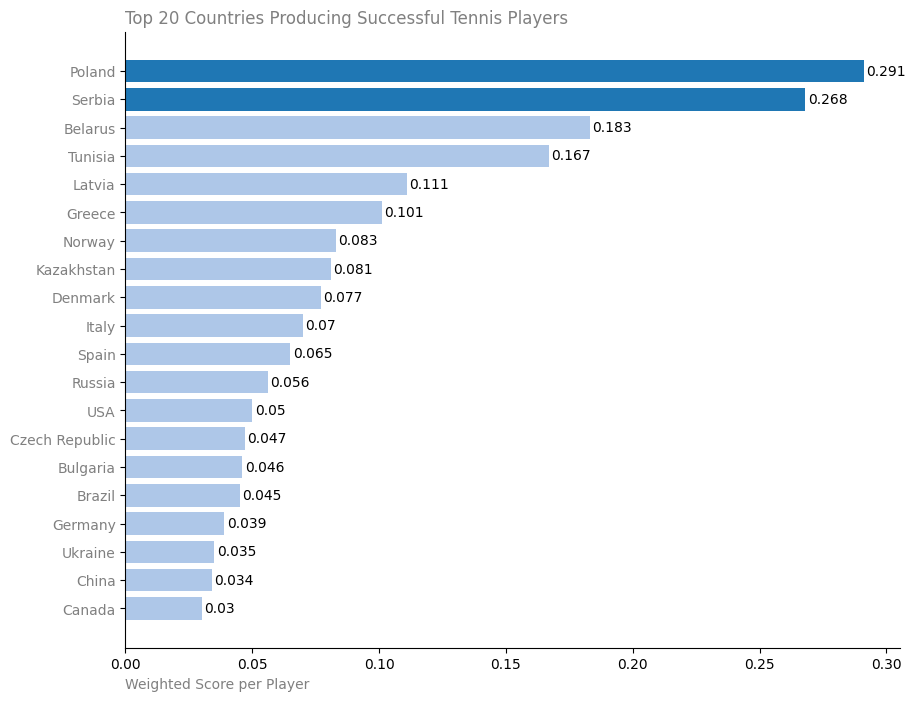

In [ ]:
# Question 6 . Which country has produced the most successful tennis players?
home = pd.read_csv(csv_files["MatchHomeTeamInfo"])
away = pd.read_csv(csv_files["MatchAwayTeamInfo"])
players = pd.concat([
    away[['player_id', 'current_rank', 'country']],
    home[['player_id', 'current_rank', 'country']]
]).drop_duplicates(subset='player_id')
players = players[(players['current_rank'] < 100) & (players['country'].notna())]
ranking = players.groupby('country').agg(
    count=('current_rank', 'count'),
    weighted_score=('current_rank', lambda x: (1 / x).sum())
).reset_index()
ranking['weighted_score_per_player'] = (ranking['weighted_score'] / ranking['count']).round(3)
ranking = ranking[['country', 'weighted_score_per_player']].sort_values(
    'weighted_score_per_player', ascending=False
).reset_index(drop=True)
print(ranking.head(20))

top20 = ranking.head(20).sort_values('weighted_score_per_player').reset_index(drop=True)
colors = ['#aec7e8'] * 18 + ['#1f77b4'] * 2  
fig, ax = plt.subplots(figsize=(10,8))
ax.barh(top20['country'], top20['weighted_score_per_player'], color=colors)
ax.set_xlabel("Weighted Score per Player", color = 'gray', loc = 'left')
ax.set_title("Top 20 Countries Producing Successful Tennis Players", color = 'gray', loc = 'left')
ax.tick_params(axis='y', labelcolor='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, v in enumerate(top20['weighted_score_per_player']):
    ax.text(v + 0.001, i, str(v), va='center')
fig.savefig("top20_countries_tennis_horizontal.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Question 7 . What is the average number of aces per match?
stats = pl.read_csv(csv_files["StatisticInfo"])
aces = stats.filter(pl.col("statistic_name").str.contains("(?i)ace"))
avg_aces = (aces["home_value"] + aces["away_value"]).mean()
print("The average number of aces per match:", round(avg_aces, 2))

The average number of aces per match: 3.26


In [ ]:
# Question 8 . Is there a difference in the number of double faults based on gender?
# Before deleting outliers
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
stats = pl.read_csv(csv_files["StatisticInfo"])
dfaults = stats.filter(pl.col("statistic_name").str.contains("(?i)double"))
home_gender = home.select(["match_id", "gender"]).rename({"gender": "gender_home"})
away_gender = away.select(["match_id", "gender"]).rename({"gender": "gender_away"})
df = dfaults.join(home_gender, on="match_id", how="left") \
            .join(away_gender, on="match_id", how="left")
df_home = df.select(["gender_home", "home_value"]).rename({"gender_home": "gender", "home_value": "df"})
df_away = df.select(["gender_away", "away_value"]).rename({"gender_away": "gender", "away_value": "df"})
df_final = pl.concat([df_home, df_away]).filter(pl.col("gender").is_not_null())
result = df_final.group_by("gender").agg(pl.col("df").mean().alias("avg_double_fault"))
print(result)

shape: (2, 2)
┌────────┬──────────────────┐
│ gender ┆ avg_double_fault │
│ ---    ┆ ---              │
│ str    ┆ f64              │
╞════════╪══════════════════╡
│ M      ┆ 1.610588         │
│ F      ┆ 2.100662         │
└────────┴──────────────────┘


In [ ]:
# Question 8 . Is there a difference in the number of double faults based on gender?
# After deleting outliers
dfaults = pl.read_csv(csv_files["StatisticInfo"]).filter(
    pl.col("statistic_name").str.contains("(?i)double")
)
home_gender = pl.read_csv(csv_files["MatchHomeTeamInfo"]).select(["match_id", "gender"]).rename({"gender": "gender_home"})
away_gender = pl.read_csv(csv_files["MatchAwayTeamInfo"]).select(["match_id", "gender"]).rename({"gender": "gender_away"})
df = (
    dfaults
    .join(home_gender, on="match_id", how="left")
    .join(away_gender, on="match_id", how="left")
)
df_home = df.select(["gender_home", "home_value"]).rename({"gender_home": "gender", "home_value": "df"})
df_away = df.select(["gender_away", "away_value"]).rename({"gender_away": "gender", "away_value": "df"})
df_final = (
    pl.concat([df_home, df_away])
    .filter(pl.col("gender").is_not_null() & pl.col("df").is_not_null())
)
def iqr_filter(df, col="df"):
    q1 = df.select(pl.col(col).quantile(0.25)).item()
    q3 = df.select(pl.col(col).quantile(0.75)).item()
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return df.filter((pl.col(col) >= low) & (pl.col(col) <= high))
cleaned_parts = []
for g in df_final.select("gender").unique().to_series():
    grp = df_final.filter(pl.col("gender") == g)
    grp_clean = iqr_filter(grp, "df")
    cleaned_parts.append(grp_clean)
df_cleaned = pl.concat(cleaned_parts)
result_clean = (
    df_cleaned.group_by("gender")
    .agg(pl.col("df").mean().alias("avg_double_fault_clean"))
)
print(result_clean)

shape: (2, 2)
┌────────┬────────────────────────┐
│ gender ┆ avg_double_fault_clean │
│ ---    ┆ ---                    │
│ str    ┆ f64                    │
╞════════╪════════════════════════╡
│ M      ┆ 1.382508               │
│ F      ┆ 1.85248                │
└────────┴────────────────────────┘


In [ ]:
# Question 8 . Is there a difference in the number of double faults based on gender?
# Findind outliers
extreme_raw = (
    df_final.group_by("gender")
    .agg([
        pl.col("df").min().alias("min_raw"),
        pl.col("df").max().alias("max_raw"),
        pl.col("df").mean().alias("mean_raw"),
        pl.len().alias("count_raw")
    ])
)
print(extreme_raw)

shape: (2, 5)
┌────────┬─────────┬─────────┬──────────┬───────────┐
│ gender ┆ min_raw ┆ max_raw ┆ mean_raw ┆ count_raw │
│ ---    ┆ ---     ┆ ---     ┆ ---      ┆ ---       │
│ str    ┆ i64     ┆ i64     ┆ f64      ┆ u32       │
╞════════╪═════════╪═════════╪══════════╪═══════════╡
│ M      ┆ 0       ┆ 21      ┆ 1.610588 ┆ 70021     │
│ F      ┆ 0       ┆ 31      ┆ 2.100662 ┆ 54509     │
└────────┴─────────┴─────────┴──────────┴───────────┘


In [ ]:
# Question 9 . Which player has won the most tournaments in a single month?
match = pl.read_csv(csv_files["MatchEventInfo"])
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
tournament = pl.read_csv(csv_files["MatchTournamentInfo"])
match_players = (
    match
    .join(home.select(["match_id", "player_id"]).rename({"player_id": "home_player_id"}), on="match_id", how="left")
    .join(away.select(["match_id", "player_id"]).rename({"player_id": "away_player_id"}), on="match_id", how="left")
    .with_columns(
        pl.when(pl.col("winner_code") == 1).then(pl.col("home_player_id"))
          .when(pl.col("winner_code") == 2).then(pl.col("away_player_id"))
          .otherwise(None)
          .alias("winner_player_id")
    )
)
tournament_full = tournament.join(
    match_players.select(["match_id", "winner_player_id", "start_datetime"]),
    on="match_id",
    how="left"
)
tournament_full = tournament_full.with_columns(
    (pl.col("start_datetime") * 1_000_000_000).cast(pl.Datetime("ns")).alias("start_dt")
).with_columns(
    (pl.col("start_dt").dt.year().cast(pl.Utf8) + "-" + pl.col("start_dt").dt.month().cast(pl.Utf8)).alias("year_month")
)
player_map = (
    pl.concat([
        home.select(["player_id", "full_name"]),
        away.select(["player_id", "full_name"])
    ])
    .unique(subset=["player_id"])
)
tournament_full = tournament_full.join(
    player_map, left_on="winner_player_id", right_on="player_id", how="left"
).filter(pl.col("full_name").is_not_null())
wins_per_month = (
    tournament_full.group_by(["full_name", "year_month"])
                   .agg(pl.count("match_id").alias("tournament_wins"))
                   .sort("tournament_wins", descending=True)
)
print(wins_per_month.head(5))

shape: (5, 3)
┌───────────────────┬────────────┬─────────────────┐
│ full_name         ┆ year_month ┆ tournament_wins │
│ ---               ┆ ---        ┆ ---             │
│ str               ┆ str        ┆ u32             │
╞═══════════════════╪════════════╪═════════════════╡
│ Popko, Dmitry     ┆ 2024-2     ┆ 32              │
│ Faria, Jaime      ┆ 2024-3     ┆ 30              │
│ Kužmová, Katarína ┆ 2024-2     ┆ 28              │
│ Gengel, Marek     ┆ 2024-2     ┆ 28              │
│ Estable, Julieta  ┆ 2024-3     ┆ 28              │
└───────────────────┴────────────┴─────────────────┘


Correlation between height and ranking: 0.078


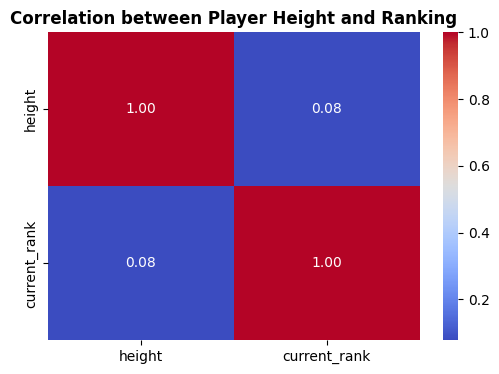

In [ ]:
# Question 10 . Is there a correlation between a player's height and their ranking?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
home_info = home.select(["full_name", "height", "current_rank"])
away_info = away.select(["full_name", "height", "current_rank"])
home_info = home_info.with_columns([
    pl.col("height").cast(pl.Float64),
    pl.col("current_rank").cast(pl.Float64)
])
away_info = away_info.with_columns([
    pl.col("height").cast(pl.Float64),
    pl.col("current_rank").cast(pl.Float64)
])
combined = pl.concat([home_info, away_info])
combined = combined.filter(
    pl.col("height").is_not_null() &
    pl.col("current_rank").is_not_null()
)
corr_value = combined.select(pl.corr("height", "current_rank")).item()
print(f"Correlation between height and ranking: {corr_value:.3f}")
corr_matrix = combined.to_pandas()[["height", "current_rank"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Player Height and Ranking", fontsize=12, weight='bold')
plt.savefig("Correlation between Player Height and Ranking", dpi=300)
plt.show()

In [ ]:
# Question 11 . What is the average duration of matches?
# Before deleting outliers
event = pl.read_csv(csv_files["MatchEventInfo"])
timeinfo = pl.read_csv(csv_files["MatchTimeInfo"])
merged = event.join(timeinfo, on="match_id", how="inner")
merged = merged.with_columns([
    (pl.col("current_period_start_timestamp") - pl.col("start_datetime")).alias("duration_sec")
])
merged = merged.filter(pl.col("duration_sec").is_not_null())
merged = merged.filter(
    (pl.col("duration_sec") > 3600) &
    (pl.col("duration_sec") <= 24 * 3600)
)
merged = merged.with_columns(
    (pl.col("duration_sec") / 60).alias("duration_min")
)
stats = merged.select([
    pl.count("duration_min").alias("samples"),
    pl.col("duration_min").min().alias("min_minutes"),
    pl.col("duration_min").max().alias("max_minutes"),
    pl.col("duration_min").mean().round(2).alias("avg_minutes"),
    pl.col("duration_min").median().round(2).alias("median_minutes"),
])
print("Match Duration Statistics (in minutes):")
print(stats)

Match Duration Statistics (in minutes):
shape: (1, 5)
┌─────────┬─────────────┬─────────────┬─────────────┬────────────────┐
│ samples ┆ min_minutes ┆ max_minutes ┆ avg_minutes ┆ median_minutes │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---            │
│ u32     ┆ f64         ┆ f64         ┆ f64         ┆ f64            │
╞═════════╪═════════════╪═════════════╪═════════════╪════════════════╡
│ 5894    ┆ 60.016667   ┆ 1365.416667 ┆ 104.56      ┆ 94.06          │
└─────────┴─────────────┴─────────────┴─────────────┴────────────────┘


In [ ]:
# Question 11 . What is the average duration of matches?
# After deleting outliers
event = pl.read_csv(csv_files["MatchEventInfo"])
timeinfo = pl.read_csv(csv_files["MatchTimeInfo"])
merged = event.join(timeinfo, on="match_id", how="inner")
merged = merged.with_columns([
    (pl.col("current_period_start_timestamp") - pl.col("start_datetime")).alias("duration_sec")
])
merged = merged.filter(pl.col("duration_sec").is_not_null())
merged = merged.filter(
    (pl.col("duration_sec") >= 3600) &      
    (pl.col("duration_sec") <= 360*60)      
)
merged = merged.with_columns(
    (pl.col("duration_sec") / 60).alias("duration_min")
)
stats = merged.select([
    pl.count("duration_min").alias("samples"),
    pl.col("duration_min").min().alias("min_minutes"),
    pl.col("duration_min").max().alias("max_minutes"),
    pl.col("duration_min").mean().round(2).alias("avg_minutes"),
    pl.col("duration_min").median().round(2).alias("median_minutes"),
])
print("Match Duration Statistics (Filtered, in minutes):")
print(stats)

Match Duration Statistics (Filtered, in minutes):
shape: (1, 5)
┌─────────┬─────────────┬─────────────┬─────────────┬────────────────┐
│ samples ┆ min_minutes ┆ max_minutes ┆ avg_minutes ┆ median_minutes │
│ ---     ┆ ---         ┆ ---         ┆ ---         ┆ ---            │
│ u32     ┆ f64         ┆ f64         ┆ f64         ┆ f64            │
╞═════════╪═════════════╪═════════════╪═════════════╪════════════════╡
│ 5871    ┆ 60.016667   ┆ 357.666667  ┆ 101.54      ┆ 93.82          │
└─────────┴─────────────┴─────────────┴─────────────┴────────────────┘


In [ ]:
# Question 12 . What is the average number of games per set in men's matches compared to women's matches?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
home_score = pl.read_csv(csv_files["MatchHomeScoreInfo"])
away_score = pl.read_csv(csv_files["MatchAwayScoreInfo"])
home_info = home.select(["match_id", "gender"])
set_cols = [f"period_{i}" for i in range(1, 6) if f"period_{i}" in home_score.columns]
home_sets = home_score.select(["match_id"] + set_cols).with_columns(
    [pl.col(c).cast(pl.Float64).fill_null(0) for c in set_cols]
)
away_sets = away_score.select(["match_id"] + set_cols).with_columns(
    [pl.col(c).cast(pl.Float64).fill_null(0) for c in set_cols]
)
total_games_df = home_sets.with_columns(
    pl.sum_horizontal([pl.col(c) + away_sets[c] for c in set_cols]).alias("total_games")
)
set_counts_df = home_sets.with_columns(
    pl.sum_horizontal([(pl.col(c) + away_sets[c]) > 0 for c in set_cols]).alias("set_count")
)
df = total_games_df.select([
    pl.col("match_id"),
    (
        pl.col("total_games") /
        pl.when(set_counts_df["set_count"] == 0)
          .then(None)
          .otherwise(set_counts_df["set_count"])
    ).alias("avg_games_per_set")
])
df = df.join(home_info, on="match_id", how="left")
df = df.filter(
    (pl.col("avg_games_per_set") >= 4) &
    (pl.col("avg_games_per_set") <= 13)
).drop_nulls(["gender"])
avg_by_gender = (
    df.group_by("gender")
      .agg(pl.col("avg_games_per_set").mean().round(2).alias("mean_avg_games"))
)
print("Average number of games per set by gender:")
print(avg_by_gender)

Average number of games per set by gender:
shape: (2, 2)
┌────────┬────────────────┐
│ gender ┆ mean_avg_games │
│ ---    ┆ ---            │
│ str    ┆ f64            │
╞════════╪════════════════╡
│ M      ┆ 9.42           │
│ F      ┆ 9.07           │
└────────┴────────────────┘


Distribution of playing hand:
shape: (2, 3)
┌──────────────────┬───────┬─────────┐
│ normalized_plays ┆ count ┆ percent │
│ ---              ┆ ---   ┆ ---     │
│ str              ┆ u32   ┆ f64     │
╞══════════════════╪═══════╪═════════╡
│ right            ┆ 1013  ┆ 88.39   │
│ left             ┆ 133   ┆ 11.61   │
└──────────────────┴───────┴─────────┘


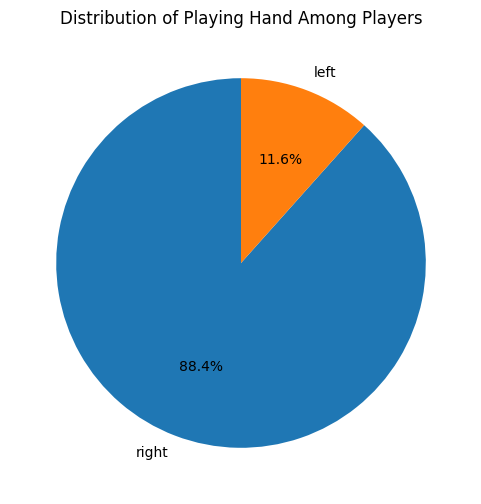

In [ ]:
# Question 13 . What is the distribution of left-handed versus right-handed players?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
players = pl.concat([
    home.select(["player_id", "plays"]),
    away.select(["player_id", "plays"])
]).unique(subset="player_id")
players = players.filter(pl.col("plays").is_not_null()).with_columns(
    pl.col("plays").cast(str).str.strip_chars().str.to_lowercase()
)
players = players.with_columns(
    pl.when(pl.col("plays").str.starts_with("r"))
      .then(pl.lit("right"))
      .when(pl.col("plays").str.starts_with("l"))
      .then(pl.lit("left"))
      .when(pl.col("plays").str.contains("two|ambi"))
      .then(pl.lit("ambidextrous"))
      .otherwise(pl.lit("unknown"))
      .alias("normalized_plays")
)
counts = (
    players.group_by("normalized_plays")
           .len()
           .sort("len", descending=True)
           .rename({"len": "count"})
)
total = counts["count"].sum()
result = counts.with_columns(
    (pl.col("count") / total * 100).round(2).alias("percent")
)
print("Distribution of playing hand:")
print(result)
labels = result['normalized_plays'].to_list()
counts = result['count'].to_list()
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
ax.set_title("Distribution of Playing Hand Among Players")
fig.savefig("playing_hand_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

Top 5 most common tournament surfaces:
shape: (5, 3)
┌───────────────────┬───────┬─────────┐
│ ground_type       ┆ count ┆ percent │
│ ---               ┆ ---   ┆ ---     │
│ str               ┆ u32   ┆ f64     │
╞═══════════════════╪═══════╪═════════╡
│ hardcourt outdoor ┆ 8093  ┆ 48.68   │
│ red clay          ┆ 5583  ┆ 33.58   │
│ hardcourt indoor  ┆ 2188  ┆ 13.16   │
│ grass             ┆ 267   ┆ 1.61    │
│ red clay indoor   ┆ 236   ┆ 1.42    │
└───────────────────┴───────┴─────────┘


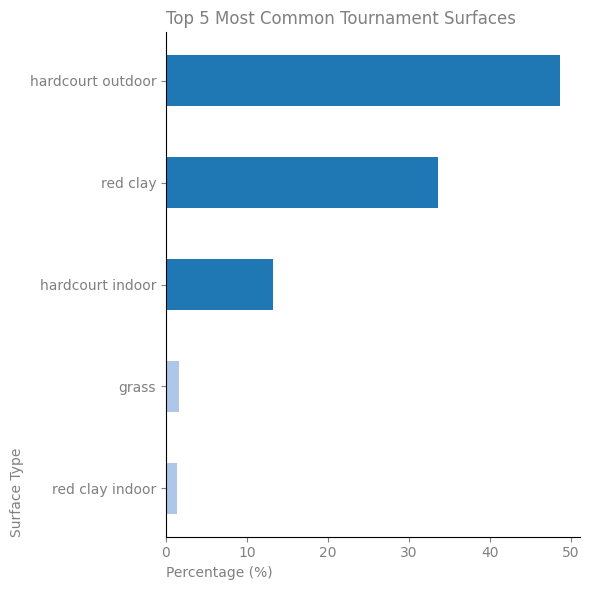

In [ ]:
# Question 14 . What is the most common type of surface used in tournaments?
tournament = pl.read_csv(csv_files["MatchTournamentInfo"])
tournament = (
    tournament
    .filter(pl.col("ground_type").is_not_null())
    .with_columns(pl.col("ground_type").cast(str).str.strip_chars().str.to_lowercase())
)
surface_stats = (
    tournament.group_by("ground_type")
        .len()
        .rename({"len": "count"})
        .sort("count", descending=True)
)
total = surface_stats["count"].sum()
surface_stats = surface_stats.with_columns(
    (pl.col("count") / total * 100).round(2).alias("percent")
).head()
print("Top 5 most common tournament surfaces:")
print(surface_stats)

ground_types = surface_stats["ground_type"].to_list()
percents = surface_stats["percent"].to_list()
plt.figure(figsize=(6,6))
colors = ['#1f77b4'] * 3 + ['#aec7e8'] * 2
plt.barh(ground_types, percents, height=0.5, color=colors)
plt.xlabel("Percentage (%)", color='gray', loc = 'left')
plt.ylabel("Surface Type", color='gray', loc = 'bottom')
plt.title("Top 5 Most Common Tournament Surfaces", loc = 'left', color = 'gray')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', colors='gray')
ax.tick_params(axis='y', colors='gray')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("Top_5_Most_Common_Tournament_Surfaces.png", dpi=300)
plt.show()

In [ ]:
# Question 15 . How many distinct countries are represented in the dataset?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
countries = (
    pl.concat([home.select("country"), away.select("country")])
    .filter(pl.col("country").is_not_null())
    .with_columns(pl.col("country").cast(str).str.strip_chars())
    .filter(pl.col("country") != "")
)
distinct_countries = countries.select(pl.col("country").unique())
country_count = distinct_countries.height
print(f"Number of distinct countries represented: {country_count}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
countries = distinct_countries.select("country").to_series().to_list()
n_cols = 4
n_rows = math.ceil(len(countries) / n_cols)
columns = [countries[i*n_rows:(i+1)*n_rows] for i in range(n_cols)]
for i in range(n_rows):
    row = []
    for col in columns:
        if i < len(col):
            row.append(f"{col[i]:<25}")
    print(" ".join(row))

Number of distinct countries represented: 101
Slovakia                  Norway                    Qatar                     Bulgaria                 
Finland                   Burundi                   Croatia                   Uzbekistan               
Jordan                    Guadeloupe                Latvia                    Spain                    
Jamaica                   Morocco                   Dominican Republic        Italy                    
Paraguay                  Slovenia                  New Caledonia             France                   
Argentina                 Philippines               Tunisia                   Russia                   
Brazil                    Monaco                    Poland                    Andorra                  
Indonesia                 Venezuela                 Switzerland               Belarus                  
Peru                      Malaysia                  Thailand                  Portugal                 
Iran              

In [ ]:
# Question 16 . Which player has the highest winning percentage against top 10 ranked opponents?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
match = pl.read_csv(csv_files["MatchEventInfo"])
home_players = home.select([
    "match_id", "player_id", "full_name", "current_rank"
]).rename({
    "player_id": "home_player_id",
    "full_name": "home_name",
    "current_rank": "home_rank"
})
away_players = away.select([
    "match_id", "player_id", "full_name", "current_rank"
]).rename({
    "player_id": "away_player_id",
    "full_name": "away_name",
    "current_rank": "away_rank"
})
matches = match.join(home_players, on="match_id", how="left")\
               .join(away_players, on="match_id", how="left")
matches = matches.with_columns([
    (pl.col("winner_code") == 1).cast(pl.Int64).alias("home_win"),
    (pl.col("winner_code") == 2).cast(pl.Int64).alias("away_win")
])
home_records = matches.select([
    pl.col("home_player_id").alias("player_id"),
    pl.col("home_name").alias("full_name"),
    pl.col("away_rank").alias("opponent_rank"),
    pl.col("home_win").alias("win")
])
away_records = matches.select([
    pl.col("away_player_id").alias("player_id"),
    pl.col("away_name").alias("full_name"),
    pl.col("home_rank").alias("opponent_rank"),
    pl.col("away_win").alias("win")
])
all_records = pl.concat([home_records, away_records])
top10_records = all_records.filter(
    (pl.col("opponent_rank") <= 10) & (pl.col("opponent_rank").is_not_null())
)
top10_records = top10_records.filter(pl.col("win").is_not_null())
winning_stats = top10_records.group_by("full_name").agg([
    pl.count("win").alias("matches_vs_top10"),
    pl.sum("win").alias("wins_vs_top10")
])
winning_stats = winning_stats.with_columns(
    (100 * pl.col("wins_vs_top10") / pl.col("matches_vs_top10")).alias("winning_percentage")
)
winning_stats = winning_stats.filter(pl.col("matches_vs_top10") >= 3)
max_percent = winning_stats["winning_percentage"].max()
top_players = winning_stats.filter(pl.col("winning_percentage") == max_percent)
top_players = top_players.sort("full_name")
all_top10_stats = winning_stats.sort("winning_percentage", descending=True)
print(all_top10_stats.head(10))

shape: (10, 4)
┌──────────────────┬──────────────────┬───────────────┬────────────────────┐
│ full_name        ┆ matches_vs_top10 ┆ wins_vs_top10 ┆ winning_percentage │
│ ---              ┆ ---              ┆ ---           ┆ ---                │
│ str              ┆ u32              ┆ i64           ┆ f64                │
╞══════════════════╪══════════════════╪═══════════════╪════════════════════╡
│ Swiatek, Iga     ┆ 3                ┆ 3             ┆ 100.0              │
│ Humbert, Ugo     ┆ 3                ┆ 3             ┆ 100.0              │
│ Kalinskaya, Anna ┆ 5                ┆ 4             ┆ 80.0               │
│ Alcaraz, Carlos  ┆ 4                ┆ 3             ┆ 75.0               │
│ Sinner, Jannik   ┆ 4                ┆ 3             ┆ 75.0               │
│ Kostyuk, Marta   ┆ 3                ┆ 2             ┆ 66.666667          │
│ Cirstea, Sorana  ┆ 3                ┆ 2             ┆ 66.666667          │
│ Jarry, Nicolas   ┆ 3                ┆ 2             ┆ 66.66

In [ ]:
# Question 17. What is the average number of breaks of serve per match?
power = pl.read_csv(csv_files["PowerInfo"])
power = power.drop_nulls(["match_id", "break_occurred"])
power = power.with_columns(pl.col("break_occurred").cast(pl.Boolean))
breaks_per_match = (
    power.group_by("match_id")
         .agg(pl.col("break_occurred").sum().alias("breaks"))
)
avg_breaks = breaks_per_match["breaks"].mean()
avg_breaks = round(avg_breaks, 2)
print(f"Average number of breaks of serve per match: {avg_breaks}")

Average number of breaks of serve per match: 6.93


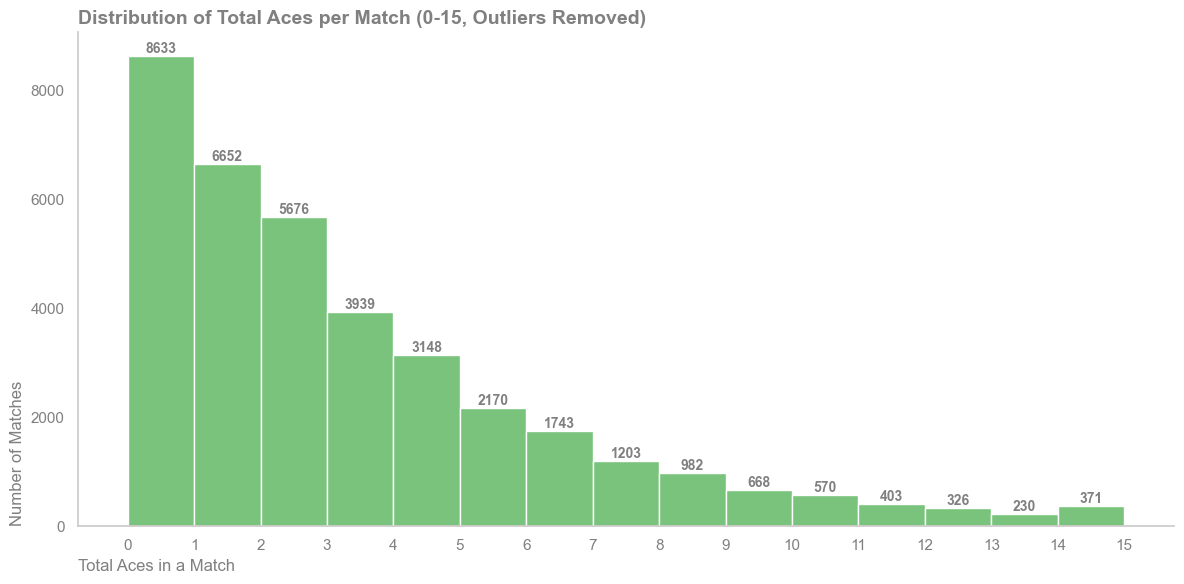

In [ ]:
# Question 18 . How are aces distributed among professional tennis players?
stats = pl.read_csv(csv_files["StatisticInfo"])
aces = stats.filter(
    pl.col("statistic_name").str.contains("(?i)ace")  
)
aces_per_match = aces.with_columns(
    (pl.col("home_value") + pl.col("away_value")).alias("total_aces")
).select(["match_id", "total_aces"])
aces_clean = aces_per_match.filter(pl.col("total_aces") <= 15)
bins = np.arange(0, 16, 1)
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
ax = sns.histplot(
    aces_clean.to_pandas()["total_aces"],  
    bins=bins,
    kde=False,
    color="#4CAF50"
)
counts, _ = np.histogram(aces_clean.to_pandas()["total_aces"], bins=bins)
for i in range(len(counts)):
    ax.text(i + 0.5, counts[i] + 2, str(counts[i]), ha='center', va='bottom', 
            fontweight='bold', fontsize=10, color='gray')
sns.despine(top=True, right=True)
plt.title("Distribution of Total Aces per Match (0-15, Outliers Removed)",
          fontsize=14, fontweight="bold", color='gray', loc='left')
plt.xlabel("Total Aces in a Match", fontsize=12, color='gray', loc='left')
plt.ylabel("Number of Matches", fontsize=12, color='gray', loc='bottom')
plt.xticks(bins)
ax.tick_params(axis='x', colors='gray')
ax.tick_params(axis='y', colors='gray')
plt.grid(False)
plt.tight_layout()
plt.savefig("aces_distribution_0_15_with_counts.png", dpi=300)
plt.show()

Votes-based prediction accuracy: 0.672  (n=16266)

Confusion matrix (rows=true, cols=pred):
[[5642 2774]
 [2569 5281]]

Classification report:
              precision    recall  f1-score   support

           1       0.69      0.67      0.68      8416
           2       0.66      0.67      0.66      7850

    accuracy                           0.67     16266
   macro avg       0.67      0.67      0.67     16266
weighted avg       0.67      0.67      0.67     16266



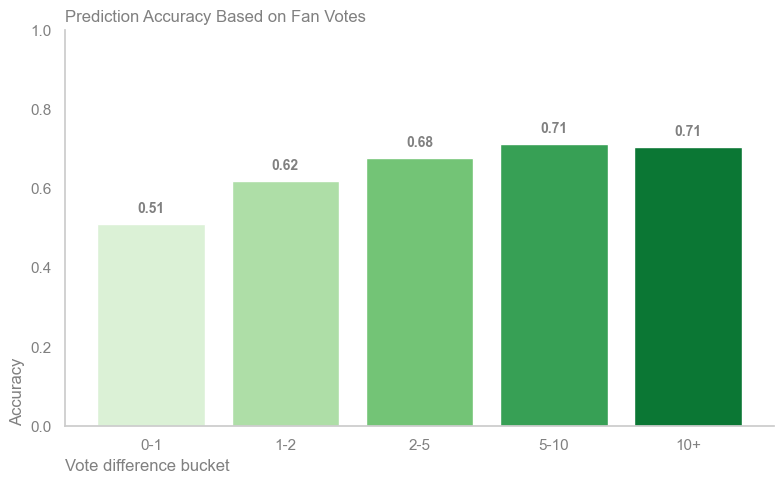

In [ ]:
# Question 19 . Can fan votes predict the winner before the match?
match = pl.read_csv(csv_files["MatchEventInfo"])
votes = pl.read_csv(csv_files["MatchVotesInfo"])
if match is None or votes is None:
    raise ValueError("Required tables not found: MatchEventInfo or MatchVotesInfo")
merged = (
    match.select(["match_id", "winner_code", "home_team_seed", "away_team_seed"])
    .join(
        votes.select(["match_id", "home_vote", "away_vote"]),
        on="match_id",
        how="inner")
    .filter(
        pl.col("winner_code").is_not_null()
        & pl.col("home_vote").is_not_null()
        & pl.col("away_vote").is_not_null())
)
merged = merged.with_columns(
    pl.when(pl.col("home_vote") > pl.col("away_vote"))
      .then(1)
      .otherwise(2)
      .alias("pred_vote")
)
y_true = merged["winner_code"].to_list()
y_pred = merged["pred_vote"].to_list()
acc_votes = accuracy_score(y_true, y_pred)
print(f"Votes-based prediction accuracy: {acc_votes:.3f}  (n={len(y_true)})\n")
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_true, y_pred, labels=[1,2]))
print("\nClassification report:")
print(classification_report(y_true, y_pred, labels=[1,2]))
merged = merged.with_columns(
    (pl.col("home_vote") - pl.col("away_vote")).abs().alias("vote_diff")
)
merged = merged.with_columns(
    pl.when(pl.col("vote_diff") <= 1).then(pl.lit("0-1"))
    .when(pl.col("vote_diff") <= 2).then(pl.lit("1-2"))
    .when(pl.col("vote_diff") <= 5).then(pl.lit("2-5"))
    .when(pl.col("vote_diff") <= 10).then(pl.lit("5-10"))
    .otherwise(pl.lit("10+"))
    .alias("diff_bucket")
)
acc_by_bucket = (
    merged.group_by("diff_bucket")
    .agg([
        (pl.col("winner_code") == pl.col("pred_vote")).mean().alias("accuracy"),
        pl.len().alias("n")
    ])
)
ordered_buckets = ["0-1", "1-2", "2-5", "5-10", "10+"]
acc_dict = {row[0]: row[1] for row in acc_by_bucket.select(["diff_bucket", "accuracy"]).to_numpy()}
accs_ordered = [acc_dict.get(b, 0) for b in ordered_buckets]
plt.figure(figsize=(8,5))
bars = plt.bar(ordered_buckets, accs_ordered, color=sns.color_palette("Greens", len(ordered_buckets)))
plt.ylim(0, 1)
plt.ylabel("Accuracy", color='gray', loc = 'bottom')
plt.xlabel("Vote difference bucket", color='gray', loc = 'left')
plt.xticks(color='gray')
plt.yticks(color='gray')
plt.title("Prediction Accuracy Based on Fan Votes", color='gray', loc='left')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             height + 0.02, f"{height:.2f}", ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color='gray')
plt.tight_layout()
plt.grid(False)
plt.savefig("prediction_by_votes.png", dpi=300)
plt.show()

shape: (2, 4)
┌──────────────┬──────┬───────────────┬───────────┐
│ plays        ┆ wins ┆ total_matches ┆ win_rate  │
│ ---          ┆ ---  ┆ ---           ┆ ---       │
│ str          ┆ u32  ┆ u32           ┆ f64       │
╞══════════════╪══════╪═══════════════╪═══════════╡
│ left-handed  ┆ 737  ┆ 1320          ┆ 55.833333 │
│ right-handed ┆ 5709 ┆ 7519          ┆ 75.92765  │
└──────────────┴──────┴───────────────┴───────────┘


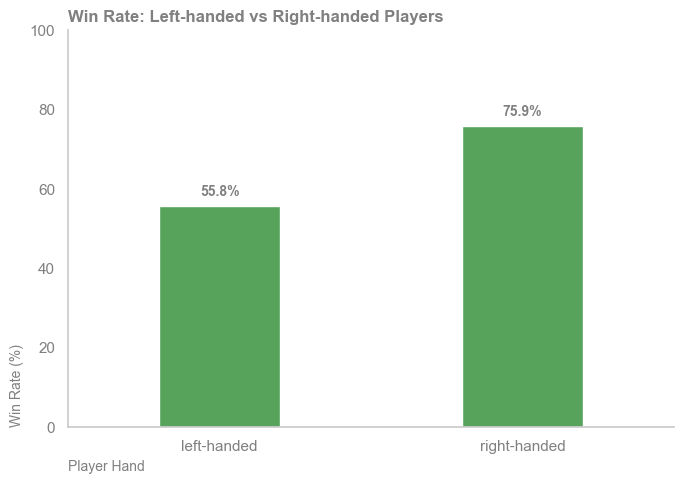

In [ ]:
# Question 20 . Is being left-handed associated with the win rate?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
match = pl.read_csv(csv_files["MatchEventInfo"])
home_unique = home.unique(subset=["match_id", "player_id"])
away_unique = away.unique(subset=["match_id", "player_id"])
match_winners = match.select(["match_id", "winner_code"])
home_win = match_winners.join(home_unique, left_on="match_id", right_on="match_id", how="left")
home_win = home_win.with_columns(
    pl.when(pl.col("winner_code") == 1).then(pl.col("player_id")).otherwise(None).alias("winner_player_id")
)
away_win = match_winners.join(away_unique, left_on="match_id", right_on="match_id", how="left")
away_win = away_win.with_columns(
    pl.when(pl.col("winner_code") == 2).then(pl.col("player_id")).otherwise(None).alias("winner_player_id")
)
winners = pl.concat([
    home_win.select(["winner_player_id", "plays"]).filter(pl.col("winner_player_id").is_not_null()),
    away_win.select(["winner_player_id", "plays"]).filter(pl.col("winner_player_id").is_not_null())
])
wins = winners.group_by("plays").agg(pl.count("winner_player_id").alias("wins"))
all_matches = pl.concat([
    home_unique.select(["match_id", "plays"]),
    away_unique.select(["match_id", "plays"])
]).unique(subset=["match_id", "plays"])
total_matches = all_matches.group_by("plays").agg(pl.count("match_id").alias("total_matches"))
win_rate = wins.join(total_matches, on="plays")
win_rate = win_rate.with_columns(
    (pl.col("wins") / pl.col("total_matches") * 100).alias("win_rate")
)
print(win_rate)
df_plot = win_rate.select(["plays", "win_rate"]).to_pandas()
plt.figure(figsize=(7,5))
sns.set(style="whitegrid")
ax = sns.barplot(
    x="plays",
    y="win_rate",
    data=df_plot,
    color="#4CAF50",
    width=0.4
)
sns.despine(top=True, right=True)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                xy=(p.get_x() + p.get_width() / 2, p.get_height()),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='gray')
plt.ylabel("Win Rate (%)", fontsize=10, loc='bottom', color='gray')
plt.xlabel("Player Hand", fontsize=10, loc='left', color='gray')
plt.title("Win Rate: Left-handed vs Right-handed Players", fontsize=12, fontweight='bold', loc='left', color='gray')
plt.ylim(0, 100)
ax.tick_params(axis='x', colors='gray')
ax.tick_params(axis='y', colors='gray')
plt.grid(False)
plt.tight_layout()
plt.savefig("win_rate_left_right.png", dpi=300)
plt.show()

In [ ]:
# Question 21 . What is the average number of tie-breaks per match?
tie_cols = [
    "period_1_tie_break",
    "period_2_tie_break",
    "period_3_tie_break",
    "period_4_tie_break",
    "period_5_tie_break"
]
home_score = pl.read_csv(csv_files["MatchHomeScoreInfo"]).select(["match_id"] + tie_cols)
away_score = pl.read_csv(csv_files["MatchAwayScoreInfo"]).select(["match_id"] + tie_cols)
home_score = home_score.with_columns([pl.col(c).cast(pl.Int32).fill_null(0) for c in tie_cols])
away_score = away_score.with_columns([pl.col(c).cast(pl.Int32).fill_null(0) for c in tie_cols])
home_tb = home_score.with_columns([
    sum([pl.when(pl.col(c) > 0).then(1).otherwise(0) for c in tie_cols]).alias("tb_count")
])
away_tb = away_score.with_columns([
    sum([pl.when(pl.col(c) > 0).then(1).otherwise(0) for c in tie_cols]).alias("tb_count")
])
tb_per_match = (
    pl.concat([
        home_tb.select(["match_id","tb_count"]),
        away_tb.select(["match_id","tb_count"])
    ])
    .group_by("match_id")
    .agg(pl.max("tb_count").alias("tb_count"))
)
avg_tb = tb_per_match.select(pl.col("tb_count").mean().alias("avg_tb"))
print("Average number of tie-breaks per match:")
print(avg_tb)

Average number of tie-breaks per match:
shape: (1, 1)
┌──────────┐
│ avg_tb   │
│ ---      │
│ f64      │
╞══════════╡
│ 0.165531 │
└──────────┘


Top players vs better-seeded opponents:
shape: (10, 5)
┌───────────┬─────────────────────┬─────────────────────┬─────────────────────┬────────────────────┐
│ player_id ┆ full_name           ┆ matches_against_bet ┆ wins_against_better ┆ winning_percentage │
│ ---       ┆ ---                 ┆ ter_seed            ┆ _seed               ┆ ---                │
│ i64       ┆ str                 ┆ ---                 ┆ ---                 ┆ f64                │
│           ┆                     ┆ u32                 ┆ i64                 ┆                    │
╞═══════════╪═════════════════════╪═════════════════════╪═════════════════════╪════════════════════╡
│ 108709    ┆ Majchrzak, Kamil    ┆ 6                   ┆ 6                   ┆ 100.0              │
│ 88318     ┆ Albie, Audrey       ┆ 9                   ┆ 8                   ┆ 88.89              │
│ 308084    ┆ Darderi, Luciano    ┆ 6                   ┆ 5                   ┆ 83.33              │
│ 152766    ┆ Helgo, Malene       ┆ 

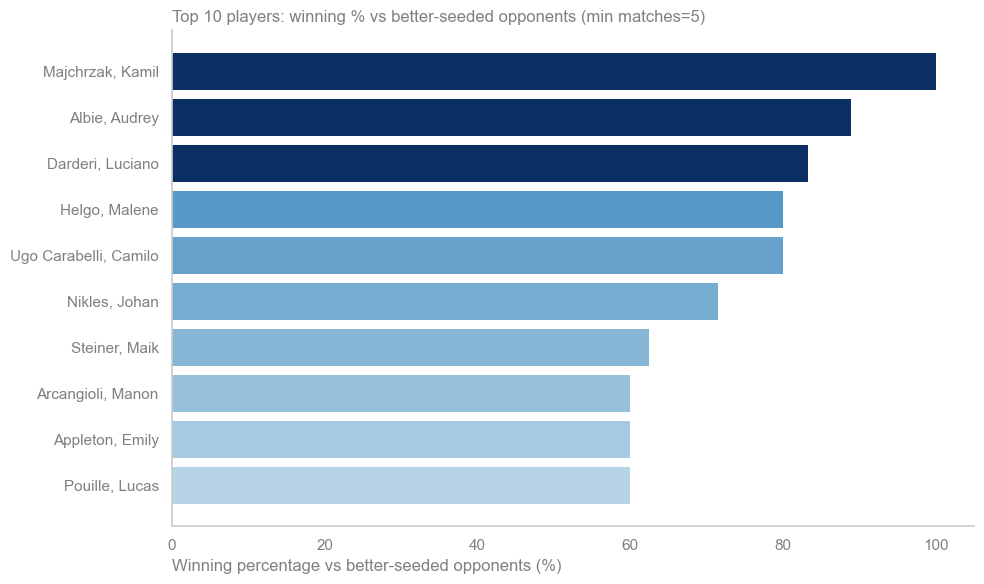

In [ ]:
# Question 22 . Which player has the highest win percentage against opponents with a better seed?
min_matches = 5   
top_k = 10
for name, df in [("match", match), ("home", home), ("away", away)]:
    if df is None:
        raise ValueError(f"DataFrame '{name}' not found in dfs")
home_sel = (
    home
    .select(["match_id", "player_id", "full_name"])
    .rename({"player_id": "home_player_id", "full_name": "home_name"}))
away_sel = (
    away
    .select(["match_id", "player_id", "full_name"]) 
    .rename({"player_id":"away_player_id", "full_name":"away_name"}))
m = (
    match
    .select(["match_id", "winner_code", "home_team_seed", "away_team_seed"])
    .join(home_sel, on="match_id", how="left")
    .join(away_sel, on="match_id", how="left")
    .unique(subset=["match_id"]))
home_records = (
    m.select([
        pl.col("match_id"),
        pl.col("home_player_id").alias("player_id"),
        pl.col("home_name").alias("full_name"),
        pl.col("home_team_seed").alias("player_seed"),
        pl.col("away_team_seed").alias("opponent_seed"),
        (pl.col("winner_code") == 1).cast(pl.Int64).alias("win")]))
away_records = (
    m.select([
        pl.col("match_id"),
        pl.col("away_player_id").alias("player_id"),
        pl.col("away_name").alias("full_name"),
        pl.col("away_team_seed").alias("player_seed"),
        pl.col("home_team_seed").alias("opponent_seed"),
        (pl.col("winner_code") == 2).cast(pl.Int64).alias("win")]))
all_records = pl.concat([home_records, away_records])
candidate = all_records.filter(
    pl.col("player_seed").is_not_null()
    & pl.col("opponent_seed").is_not_null()
    & (pl.col("opponent_seed") < pl.col("player_seed"))) 
candidate = candidate.filter(pl.col("player_id").is_not_null() & pl.col("full_name").is_not_null())
stats = (
    candidate.group_by(["player_id", "full_name"])
    .agg([
        pl.len().alias("matches_against_better_seed"),
        pl.sum("win").alias("wins_against_better_seed")])
    .with_columns(
        (100.0 * pl.col("wins_against_better_seed") / pl.col("matches_against_better_seed"))
        .round(2)
        .alias("winning_percentage")))
final = (
    stats.filter(pl.col("matches_against_better_seed") >= min_matches)
         .sort("winning_percentage", descending=True))
print("Top players vs better-seeded opponents:")
print(final.head(top_k))
top_plot = final.head(top_k).to_pandas()
plt.figure(figsize=(10,6))
n = len(top_plot)
colors = []
top_color = "#0b2f63" 
base_color_start = 0.75  
base_color_end = 0.25    

for i in range(n):
    if i < 3:
        colors.append(top_color)
    else:
        factor = base_color_start - ((i - 3) / (n - 3)) * (base_color_start - base_color_end)
        colors.append((31/255, 119/255, 180/255, factor))
plt.barh(
    top_plot["full_name"].iloc[::-1],
    top_plot["winning_percentage"].iloc[::-1],
    edgecolor="none",
    color=colors[::-1])  
plt.xlabel("Winning percentage vs better-seeded opponents (%)", loc='left', color='gray')
plt.xticks(color='gray')
plt.yticks(color='gray')
plt.title(f"Top {top_k} players: winning % vs better-seeded opponents (min matches={min_matches})",
          color='gray', loc='left')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.tight_layout()
plt.grid(False)
plt.savefig("Winning percentage vs better-seeded opponents", dpi = 300)
plt.show()

In [ ]:
# Question 23 . What are the earliest and latest match dates recorded in the dataset?
match = pl.read_csv(csv_files["MatchEventInfo"])
if match is None:
    raise ValueError("MatchEventInfo table not found in dfs")
print("Columns:", match.columns)
match_time = match.filter(pl.col("start_datetime").is_not_null()).select("start_datetime")
time_min = match_time.select(pl.col("start_datetime").min()).item()
time_max = match_time.select(pl.col("start_datetime").max()).item()
first_date = datetime.fromtimestamp(time_min, UTC)
last_date = datetime.fromtimestamp(time_max, UTC)
print(f"First match date: {first_date.strftime('%Y-%m-%d %H:%M:%S')} UTC")
print(f"Last match date:  {last_date.strftime('%Y-%m-%d %H:%M:%S')} UTC")

Columns: ['match_id', 'first_to_serve', 'home_team_seed', 'away_team_seed', 'custom_id', 'winner_code', 'default_period_count', 'start_datetime', 'match_slug', 'final_result_only']
First match date: 2024-01-31 12:05:00 UTC
Last match date:  2024-04-01 13:40:00 UTC


shape: (3, 2)
┌─────────┬─────────────┐
│ gender  ┆ num_players │
│ ---     ┆ ---         │
│ str     ┆ u32         │
╞═════════╪═════════════╡
│ M       ┆ 1404        │
│ F       ┆ 1234        │
│ Unknown ┆ 7           │
└─────────┴─────────────┘


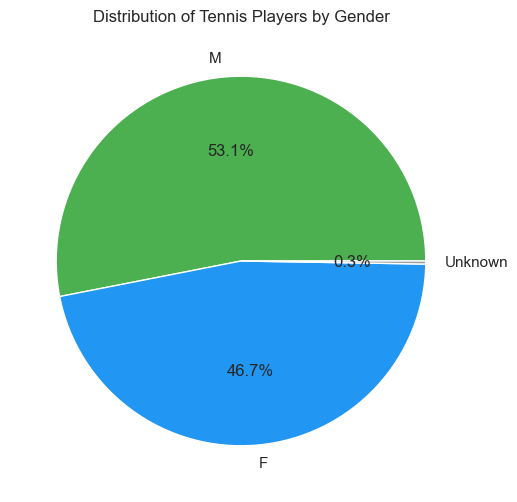

In [ ]:
# Question 24 . How many unique players in the dataset are male, female, or have an unknown gender?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"]).select(["player_id", "gender"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"]).select(["player_id", "gender"])
players = pl.concat([home, away])
players = players.with_columns(
    pl.col("gender").fill_null("Unknown")
)
players = players.unique(subset="player_id").filter(pl.col("gender").is_not_null())
gender_counts = players.group_by("gender").len().rename({"len": "num_players"})
print(gender_counts)
df_plot = gender_counts.to_pandas()
plt.figure(figsize=(6,6))
colors = ["#4CAF50", "#2196F3", "#9E9E9E"]  
plt.pie(df_plot["num_players"], labels=df_plot["gender"], autopct="%1.1f%%", colors=colors)
plt.title("Distribution of Tennis Players by Gender")
plt.savefig("Distribution of players", dpi = 300)
plt.show()


Correlation (Top-20 players vs hosted matches): 0.293
Correlation (Top-100 players vs hosted matches): 0.361


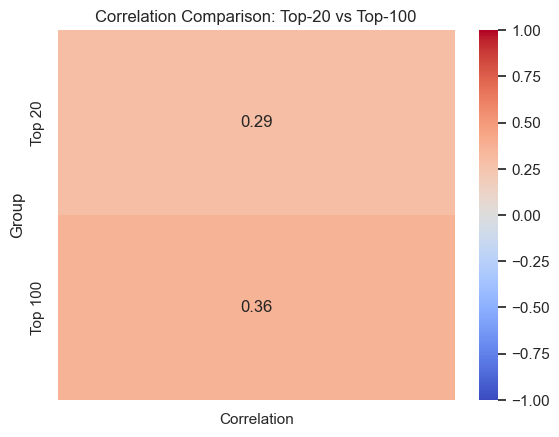

In [ ]:
# Question 25 . other version
# Question 25 . Are the countries that host the tournaments the same countries that have a lot of Top 100 players?
home = pl.read_csv(csv_files["MatchHomeTeamInfo"])
away = pl.read_csv(csv_files["MatchAwayTeamInfo"])
venue = pl.read_csv(csv_files["MatchVenueInfo"])
players = (
    pl.concat([
        home.select(["player_id", "country", "current_rank"]),
        away.select(["player_id", "country", "current_rank"])
    ])
    .unique(subset="player_id")
    .filter(pl.col("country").is_not_null())
    .with_columns(
        pl.col("country").cast(str).str.strip_chars().str.to_lowercase()
    )
)
venue_clean = (
    venue
    .filter(pl.col("country").is_not_null())
    .with_columns(
        pl.col("country").cast(str).str.strip_chars().str.to_lowercase()
    )
)
host_counts = (
    venue_clean
    .group_by("country")
    .len()
    .rename({"len": "num_hosted_matches"})
)
def compute_corr(k):
    topK = players.filter(pl.col("current_rank") <= k)
    topK_counts = (
        topK.group_by("country")
            .len()
            .rename({"len": f"num_top{k}_players"})
    )
    merged = topK_counts.join(host_counts, on="country", how="inner")
    corr_val = merged.select(
        pl.corr(f"num_top{k}_players", "num_hosted_matches")
    ).item()
    return corr_val, merged
corr20, merged20 = compute_corr(20)
corr100, merged100 = compute_corr(100)
print(f"Correlation (Top-20 players vs hosted matches): {corr20:.3f}")
print(f"Correlation (Top-100 players vs hosted matches): {corr100:.3f}")

df_corr = pd.DataFrame({
    "Group": ["Top 20", "Top 100"],
    "Correlation": [corr20, corr100]
}).set_index("Group")
sns.heatmap(df_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Comparison: Top-20 vs Top-100")
plt.savefig("Top20_vs_Top100_Correlation.png", dpi=300)
plt.show()

In [ ]:
#26.How does the first serve success rate efects the likelihood of winnig a match across difrent surface types?(clay,grass,hard)
stats = pd.read_csv(csv_files["StatisticInfo"])
tournament = pd.read_csv(csv_files['MatchTournamentInfo'])
match = pd.read_csv(csv_files['MatchEventInfo'])
def extract_percentage(value):
    if isinstance(value, (int, float)):
        return value
    if isinstance(value, str):
        match = re.search(r'\((\d+)%\)', value)
        if match:
            return float(match.group(1))
    return None
stats['home_stat'] = stats['home_stat'].apply(extract_percentage)
stats['away_stat'] = stats['away_stat'].apply(extract_percentage)
stats = stats[(stats['statistic_name'] == 'first_serve_points') &
              (stats['period'] == 'ALL')]
stats = pd.merge(match[['match_id','winner_code']],
                 stats[['match_id','statistic_name','period','home_stat','away_stat']],
                 how='inner',
                 on='match_id')
serve_performance = pd.merge(stats,
         tournament[['match_id','ground_type']],
         how='inner',
         on='match_id').assign(
             winner_first_serve_point_percent = lambda df:np.where(df['winner_code'] == 1 , df['home_stat'] , df['away_stat']),
             loser_first_serve_point_percent = lambda df:np.where(df['winner_code'] == 1 , df['away_stat'] , df['home_stat'])
         )
serve_performance1 = serve_performance[['winner_first_serve_point_percent',
                                       'loser_first_serve_point_percent',
                                       'ground_type']].assign(
    serve_diff = lambda df: df['winner_first_serve_point_percent'] - df['loser_first_serve_point_percent']
) 
serve_performance2=serve_performance1.groupby('ground_type')['serve_diff'].mean().round(1)      
serve_performance2.to_frame().sort_values(by='serve_diff',ascending=False)                

,serve_diff
ground_type,
Red clay indoor,15.0
Green clay,14.7
Synthetic outdoor,14.3
Red clay,14.2
Grass,13.9
Hardcourt outdoor,13.5
Hardcourt indoor,13.3
Carpet indoor,13.1


In [ ]:
# Question 27. How does set length (short/medium/long) affect the likelihood of Home or Away winning?
match = pd.read_csv(csv_files["MatchEventInfo"])
home = pd.read_csv(csv_files["MatchHomeScoreInfo"])
away = pd.read_csv(csv_files["MatchAwayScoreInfo"])
set_cols = [col for col in home.columns 
            if col.startswith("period_") and "_tie_break" not in col]
sets = []
for col in set_cols:
    df = pd.DataFrame({
        "match_id": home["match_id"],
        "set_name": col,
        "home_games": home[col],
        "away_games": away[col]
    })
    df["game_diff"] = (df["home_games"] - df["away_games"]).abs()
    sets.append(df)
all_sets = pd.concat(sets, ignore_index=True)
all_sets = all_sets.dropna(subset=["home_games", "away_games"])
def classify(diff):
    if diff >= 4:
        return "Short (one-sided)"
    elif diff >= 2:
        return "Medium"
    else:
        return "Long (tight)"
all_sets["set_type"] = all_sets["game_diff"].apply(classify)
sets_merged = all_sets.merge(
    match[["match_id", "winner_code"]],
    on="match_id",
    how="left"
)
sets_merged["winner"] = sets_merged["winner_code"].map({1: "Home", 2: "Away"})
result = (
    sets_merged.groupby(["set_type", "winner"])
    .size()
    .reset_index(name="count")
)
result["percent"] = (
    result.groupby("set_type")["count"]
          .transform(lambda x: 100 * x / x.sum())
          .round(1)
)
final_set_analysis = result.sort_values(by=["set_type", "percent"], ascending=[True, False])
final_set_analysis

,set_type,winner,count,percent
1,Long (tight),Home,1905,50.8
0,Long (tight),Away,1848,49.2
3,Medium,Home,8972,50.8
2,Medium,Away,8680,49.2
5,Short (one-sided),Home,8074,52.8
4,Short (one-sided),Away,7221,47.2
